<a href="https://colab.research.google.com/github/AmyBadr/Simple-NeuralNetwork-/blob/master/src/Digit_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Phase 1 ~ Block 1: Imports and Data Loading
# *******************************Prepare the "FEMNIST" Data*******************************
import tensorflow as tf
from tensorflow.keras import layers

# Load the dataset (Handwritten digits)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize: Changes pixel values from 0-255 to 0-1
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
# Normalize the images to [-1, 1]
train_images = (train_images - 127.5) / 127.5

#****************************Build the "Recognizer" (The Brain)******************************
recognition_model = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 outputs for 10 digits
])

recognition_model.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

# Train it for 5 rounds (epochs)
recognition_model.fit(train_images, train_labels, epochs=5)

#Load and Prepare the "FEMNIST" Data
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Download the data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# 2. Reshape and Normalize
# We tell the model these are 28x28 images with 1 color channel (grayscale)
train_images = (train_images.reshape(60000, 28, 28, 1).astype('float32') - 127.5) / 127.5
test_images = (test_images.reshape(10000, 28, 28, 1).astype('float32') - 127.5) / 127.5

print("Data is ready!")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9444 - loss: 0.1893
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9796 - loss: 0.0667
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0467
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9887 - loss: 0.0357
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9914 - loss: 0.0260
Data is ready!


In [4]:
#Phase 1 ~ Block 2: Build the Model Architecture
model = models.Sequential([
    # First layer: Looks for simple edges and lines
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second layer: Looks for more complex shapes like curves
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening: Turns the 2D image into a 1D list of features
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output: 10 nodes (one for each digit 0-9)
    layers.Dense(10, activation='softmax')
])

model.summary() # This shows you the "map" of your model

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Phase 1 ~ Block 3: Training and Evaluation
#*******************************Compile and Train the Model*******************************
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train for 5 "epochs" (rounds of looking at the whole dataset)
model.fit(train_images, train_labels, epochs=5, validation_split=0.1)

#**********************************Evaluate the Results*************************************
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nAccuracy on new images: {test_acc*100:.2f}%')

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9585 - loss: 0.1372 - val_accuracy: 0.9873 - val_loss: 0.0438
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9857 - loss: 0.0455 - val_accuracy: 0.9883 - val_loss: 0.0400
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0317 - val_accuracy: 0.9897 - val_loss: 0.0350
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9912 - val_loss: 0.0316
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.9897 - val_loss: 0.0358
313/313 - 1s - 3ms/step - accuracy: 0.9910 - loss: 0.0275

Accuracy on new images: 99.10%


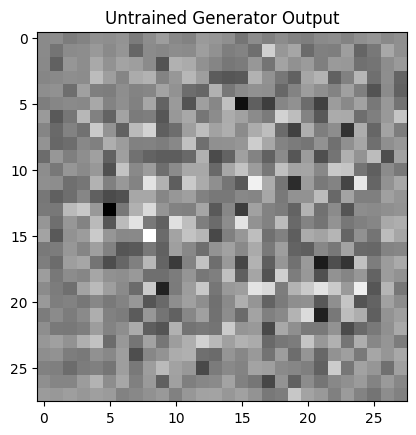

In [6]:
# Phase 2: The Generator Input Layer (The Artist)
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Generator Architecture
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        # Start with a small, dense foundation (7x7)
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        # Upsample to 14x14
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample to 28x28 (The size of our MNIST digits)
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Final layer: Produces the grayscale image
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = build_generator()

# 2. Create "Noise" and Generate an Image
# This creates a random vector of 100 numbers
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

# 3. Visualize the "Untrained" Output
# Since it hasn't learned yet, it will just look like static/noise
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("Untrained Generator Output")
plt.show()

In [7]:
#Phase 3: Block 1:Build the Discriminator (The "Police")
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3), # Helps prevent the "Police" from getting too smart too fast

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1) # Output: High number = Real, Low number = Fake
    ])
    return model

discriminator = build_discriminator()

In [8]:
#Phase 3: Block 2: Compile the Discriminator (Define Loss and Optimizers)
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# How we measure the Discriminator's success
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# How we measure the Generator's success (it wins if the police think fake is real)
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Separate "brains" for each model so they can learn independently
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [9]:
#The "Safety Net" Code (Checkpoints)
# This allows us to save the progress of our models so we can come back to it later if needed (In TensorFlow, we use a Checkpoint object. This saves not just the images, but the "weights" (the brain's state) and the "optimizers" (the learning progress) for both the Generator and the Discriminator.)
import os

# Create a folder to stay organized
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

# This object tracks everything you want to save
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [10]:
# --- BLOCK D: RESUME PROGRESS ---
# If you want to continue training from the last checkpoint, you can use this function to restore the latest checkpoint. It will load the most recent saved state of both the Generator and Discriminator, along with their optimizers, allowing you to pick up right where you left off without losing any progress.
# This restores the latest save from your folder

# This looks in your folder for the most recent save file
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)

if latest_checkpoint:
    checkpoint.restore(latest_checkpoint)
    print(f"Success! Restored progress from: {latest_checkpoint}")
else:
    print("No checkpoint found. Starting from scratch (Epoch 1).")

No checkpoint found. Starting from scratch (Epoch 1).


In [11]:
#Phase 3: Block 3:The Training Loop (The "Fight")
EPOCHS = 50
noise_dim = 100
BATCH_SIZE = 256

# We prepare the data into batches for faster processing
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(BATCH_SIZE)

@tf.function # This makes the code run much faster
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Apply the math to update the models
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Final Loop to start the training
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        # --- ADD THIS PART ---
        # Save the model every 5 epochs so you don't lose too much progress
        if (epoch + 1) % 5 == 0:
            checkpoint.save(file_prefix = checkpoint_prefix)
            print(f"Checkpoint saved at epoch {epoch + 1}")
        # ---------------------
        print(f"Epoch {epoch + 1} completed")

# Start the training!
# WARNING: This will take a few minutes depending on your computer/Colab
train(train_dataset, EPOCHS)

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Checkpoint saved at epoch 5
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Checkpoint saved at epoch 10
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Checkpoint saved at epoch 15
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Checkpoint saved at epoch 20
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Checkpoint saved at epoch 25
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Checkpoint saved at epoch 30
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Checkpoint saved at epoch 35
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Checkpoint saved at epoch 40
Epoch 40 completed
Epoch 41 completed

In [ ]:
#Phase 3:Block 4: Seeing the Final Result
def generate_and_show():
    noise = tf.random.normal([1, 100])
    prediction = generator(noise, training=False)
    plt.imshow(prediction[0, :, :, 0], cmap='gray')
    plt.axis('off')
    plt.show()

generate_and_show()

In [ ]:
#If you want to save the final model after training, you can use the following code. This will save the Generator's architecture and weights in a file called 'my_generator_model_epoch6.h5'. You can later load this model to generate images without needing to retrain it.

#If i want to stop trainging and save the model at this point, I can use the following code. This will save the Generator's architecture and weights in a file called 'my_generator_model_epoch6.h5'. You can later load this model to generate images without needing to retrain it.
generator.save('my_generator_model_epoch7.h5')
print("Model saved successfully!")

In [ ]:
# Manual save for Epoch 8
checkpoint.save(file_prefix = checkpoint_prefix)
print("Manual save of Epoch 8 complete!")

In [ ]:
# This runs only AFTER the train() function is completely finished
train(train_dataset, EPOCHS)
generator.save('final_generator_model.h5')